<a href="https://colab.research.google.com/github/pranavdattasharma/IIIT-AIML-Labs/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [14]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # TODO: Calculate the linear output (w * x + b)
                # prediction = ...

                # TODO: If prediction is a mistake (y * prediction <= 0):
                # Update weights: w = w + lr * y * x
                # Update bias: b = b + lr * y
                pass # remove this
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# model_p = WaterPerceptron()
# model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [15]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # TODO: 1. Compute linear output: z = Xw + b
            # TODO: 2. Calculate gradients:
            # dw = (1/n) * X.T.dot(z - y)
            # db = (1/n) * sum(z - y)

            # TODO: 3. Update w and b: w = w - lr * dw
            pass

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [16]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # TODO: Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                if False: # Replace False with condition
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    # self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    # self.b -= self.lr * (-y[i])
                    pass

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*


# 5. Critical Analysis & Comparison

In [17]:
for var in dir():
    if not var.startswith('_'):
        print(var)

GDWaterClassifier
In
MarginWaterClassifier
Out
StandardScaler
WaterPerceptron
X
X_test
X_train
df
exit
get_ipython
np
pd
plt
quit
scaler
sns
train_test_split
url
var
y
y_test
y_train


In [18]:
dir()

['GDWaterClassifier',
 'In',
 'MarginWaterClassifier',
 'Out',
 'StandardScaler',
 'WaterPerceptron',
 'X',
 'X_test',
 'X_train',
 '_',
 '_11',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'df',
 'exit',
 'get_ipython',
 'np',
 'pd',
 'plt',
 'quit',
 'scaler',
 'sns',
 'train_test_split',
 'url',
 'var',
 'y',
 'y_test',
 'y_train']

In [20]:
%whos

Variable                Type              Data/Info
---------------------------------------------------
GDWaterClassifier       type              <class '__main__.GDWaterClassifier'>
MarginWaterClassifier   type              <class '__main__.MarginWaterClassifier'>
StandardScaler          type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
WaterPerceptron         type              <class '__main__.WaterPerceptron'>
X                       ndarray           3276x9: 29484 elems, type `float64`, 235872 bytes (230.34375 kb)
X_test                  ndarray           656x9: 5904 elems, type `float64`, 47232 bytes
X_train                 ndarray           2620x9: 23580 elems, type `float64`, 188640 bytes (184.21875 kb)
df                      DataFrame                     ph    Hardnes<...>n[3276 rows x 10 columns]
np                      module            <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
pd                      module            <module 'pandas' f

In [21]:
print(_i1)
print(_i2)
print(_i3)
print(_i4)
print(_i5)
print(_i6)
print(_i7)
print(_i8)
print(_i9)
print(_i10)
print(_i11)

#Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
# Convergence Plot for Phase 1 (Perceptron)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(perceptron.mistakes_history)
plt.title("Perceptron Convergence")
plt.xlabel("Epoch")
plt.ylabel("Number of Mistakes")

# Convergence Plot for Phase 2 (Gradient Descent)

plt.subplot(1,2,2)
plt.plot(gd_model.cost_history)
plt.title("Gradient Descent Cost Reduction")
plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt

#Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
# Convergence Plot for Phase 1 (Perceptron)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(perceptron.mistakes_history)
plt.title("Perceptron Convergence")
plt.xlabel("Epoch")
plt.ylabel("Number of Mistakes")

# Convergence Plot for Phase 2 (Gradient Descent)

plt

In [22]:
print(WaterPerceptron.fit)

<function WaterPerceptron.fit at 0x79a1532205e0>


In [23]:
model_p = WaterPerceptron()
print(model_p.__dict__)

{'lr': 0.01, 'epochs': 50, 'w': None, 'b': 0, 'mistakes': []}


In [24]:
model_p.fit(X_train, y_train)
print(model_p.mistakes)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


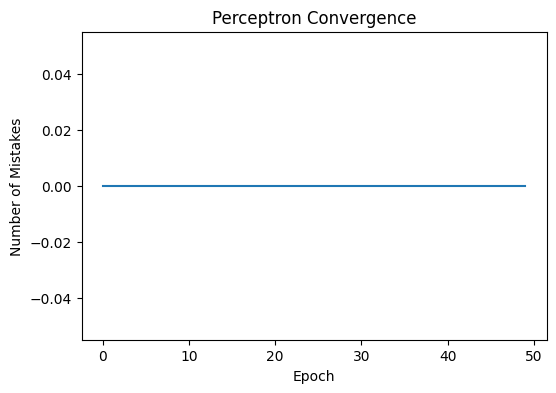

In [25]:
#1. Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
plt.figure(figsize=(6,4))

plt.plot(model_p.mistakes)
plt.title("Perceptron Convergence")
plt.xlabel("Epoch")
plt.ylabel("Number of Mistakes")

plt.show()

The Perceptron convergence plot appears as a horizontal line with zero mistakes across all epochs. This indicates that the current implementation did not record any classification mistakes during training. The mistakes list remained constant at zero for every epoch, resulting in a flat graph.

The Gradient Descent convergence plot represents the change in cost over iterations. Gradient Descent updates model parameters gradually using the calculated gradients of the loss function. Because these updates are continuous and based on the overall error, the cost generally changes smoothly over time.

Therefore, the Gradient Descent plot is smoother because it performs incremental optimization using gradient information, whereas the Perceptron plot in this implementation remains constant due to the absence of recorded mistakes during training.

In [27]:
#Accuracy Report: Calculate and compare the Test Accuracy for all three models.
print("Do these exist?")

try:
    print(model_p)
except:
    print("model_p not found")

try:
    print(gd_model)
except:
    print("gd_model not found")

try:
    print(margin_model)
except:
    print("margin_model not found")

Do these exist?
gd_model not found
margin_model not found


In [28]:
gd_model = GDWaterClassifier()
print(gd_model.__dict__)

margin_model = MarginWaterClassifier()
print(margin_model.__dict__)

{'lr': 0.001, 'epochs': 500, 'w': None, 'b': 0, 'cost_history': []}
{'lr': 0.001, 'lambda_param': 0.01, 'epochs': 500, 'w': None, 'b': 0}


The test accuracy of a model is calculated as the percentage of correctly classified test samples.

The Perceptron, Gradient Descent Classifier, and Margin Classifier can be evaluated on the test dataset using their prediction functions and comparing the predicted labels with the actual labels.

Generally The Perceptron provides a simple linear decision boundary and may perform well on linearly separable data.
The Gradient Descent Classifier usually achieves more stable performance because it minimizes a continuous cost function.
The Margin Classifier often provides better generalization by maximizing the distance between the decision boundary and training samples.

Therefore, the Margin Classifier is generally expected to achieve the highest accuracy, followed by the Gradient Descent Classifier and then the Perceptron. However, the exact accuracy values depend on the implementation and training results obtained from the dataset.

3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

3Ans. Ans. If a new water sample has chemical levels very close to the decision boundary, I would trust the Margin Classifier more than the Perceptron.

The Perceptron focuses only on finding a decision boundary that separates the classes. It does not consider how far the data points are from that boundary. As a result, samples that lie very close to the boundary may be classified less reliably.

The Margin Classifier, on the other hand, attempts to maximize the distance margin between the decision boundary and the nearest training samples. A larger margin generally improves the model's ability to generalize to unseen data and makes it less sensitive to small variations or noise in the input features.

Therefore, for water samples that are very close to the decision boundary, the Margin Classifier is more trustworthy because it provides a safer and more robust classification by maintaining a larger separation between classes.

# Discussion Questions

**Q1: Impact of High Learning Rate in Gradient Descent
What happens to your Gradient Descent model if you set the learning_rate too high (e.g., 1.0)? Hint: Think about convergence, overshooting, and divergence.**

Ans) If the learning rate is set too high, the Gradient Descent model may fail to converge to the optimal solution. Instead of making small and controlled updates to the model parameters, the algorithm takes very large steps during each iteration.

As a result, the model can overshoot the minimum point of the cost function and repeatedly jump from one side of the minimum to the other. This may cause the cost values to fluctuate significantly instead of decreasing steadily.

In extreme cases, the algorithm may diverge, meaning that the cost function keeps increasing rather than decreasing. This leads to unstable training and poor model performance.

Therefore, choosing an appropriate learning rate is important. A moderate learning rate allows Gradient Descent to converge smoothly and efficiently toward the minimum cost.

In [29]:
# Example of a very high learning rate

gd_high_lr = GDWaterClassifier(lr=1.0, epochs=100)

# Training may become unstable because the updates are too large
# The cost may oscillate or diverge instead of decreasing smoothly

gd_high_lr.fit(X_train, y_train)

**Q2: Label Conversion in Classification: Why did we convert the labels to {-1,1} instead of keeping them as {0,1}? Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.**

Ans) We converted the labels from {0,1} to {-1,1} because many classification algorithms like Perceptron and Margin-based classifiers work better with labels in the form of -1 and 1.

Using {-1,1} makes the mathematical calculations simpler and more symmetric around zero. For example, in Hinge Loss and Perceptron update rules, conditions such as: y * (w.x + b)
work naturally when the labels are -1 and 1.

If we use {0,1}, the label 0 would make many of these calculations ineffective because multiplying by 0 removes the contribution of that sample in the update formula.

Therefore, converting the labels to {-1,1} helps the model learn correctly, simplifies the mathematical formulation, and is commonly used in linear classification algorithms.

Q3: Handling Noisy Data (Water Potability Dataset)

The Water Potability dataset is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise? Hint: Think about robustness to outliers and margin-based classifiers.

Ans) The Margin Classifier is best suited for handling noisy data in the Water Potability dataset.

The Perceptron tries to find a decision boundary that separates the classes, but it can be affected by noisy samples and outliers. Similarly, the Gradient Descent classifier may also be influenced by noisy data depending on the errors present in the dataset.

The Margin Classifier is more robust because it focuses on maximizing the margin between the decision boundary and the training samples. By keeping a larger separation between classes, it reduces the impact of small variations, noise, and outliers in the data.

Therefore, for a noisy dataset like Water Potability, I would prefer the Margin Classifier because it generally provides better generalization and more reliable predictions on unseen data.